# Image Analysis and Text Analysis

Two topics that sound like they need a whole new toolkit, and don't.

You've already built a classifier on the Titanic data: a neat table of rows and columns, one row per passenger, numbers in every cell. Then the LMS hands you images and text and it feels like starting again. Photos aren't a table. Sentences aren't a table.

**Here's the whole secret of this notebook, and it's genuinely the only idea in it:**

> Image analysis and text analysis are not new kinds of machine learning. They're techniques for turning pictures and words **into a table of numbers**. Once you have the table, it's the same machine learning you already know.

That's it. Everything below is about building that table, twice: once from pictures, once from sentences.

**What you need:** scikit-learn and matplotlib. No downloads, the image data ships with scikit-learn and the text data is written into the notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print("Ready.")

Ready.


---
# Part 1 , An image is already numbers

This is the bit that surprises people, so let's get it out of the way first.

A digital image is a **grid of numbers**. Each number says how bright one dot (a pixel) is. Your screen turns those numbers into light, your eye turns the light into a picture, and somewhere in the middle your brain does something clever. But on disk, it's numbers in a grid.

We'll use a set of handwritten digits that comes bundled with scikit-learn. Each one is a tiny 8 by 8 image of a single digit, and somebody has already labelled which digit it is.

In [2]:
from sklearn.datasets import load_digits

digits = load_digits()

print("Number of images:", len(digits.images))
print("Size of each image:", digits.images[0].shape)
print("Possible labels:", sorted(set(digits.target)))

Number of images: 1797
Size of each image: (8, 8)
Possible labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


1,797 images, each 8 by 8, each labelled with the digit it shows.

Now the important bit. Let's look at one image **as numbers**, which is what it actually is.

In [3]:
# Print the first image as a grid of numbers.
# Each value is a brightness, from 0 (black) to 16 (white).
print("This is image number 0, as the computer stores it:\n")
print(digits.images[0].astype(int))
print("\nIts label is:", digits.target[0])

This is image number 0, as the computer stores it:

[[ 0  0  5 13  9  1  0  0]
 [ 0  0 13 15 10 15  5  0]
 [ 0  3 15  2  0 11  8  0]
 [ 0  4 12  0  0  8  8  0]
 [ 0  5  8  0  0  9  8  0]
 [ 0  4 11  0  1 12  7  0]
 [ 0  2 14  5 10 12  0  0]
 [ 0  0  6 13 10  0  0  0]]

Its label is: 0


**Look at that grid and squint.** The zeros form a ring of empty space, and the higher numbers trace a rough circle with a hole in the middle. That's a handwritten **0**, drawn in numbers.

You can genuinely see it. That's not a metaphor, the shape is right there in the digits.

Now the same data, drawn as an actual picture.

In [4]:
fig, axes = plt.subplots(1, 6, figsize=(12, 2.5))

for ax, i in zip(axes, range(6)):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"label: {digits.target[i]}")
    ax.axis('off')

plt.suptitle("The same numbers, drawn as pictures")
plt.show()

<Figure size 1200x250 with 6 Axes>

> 💡 **The point of Part 1.** Nothing was converted. The picture and the grid of numbers are the same thing, shown two ways. When someone says "the computer looks at the image", this is what it looks at.

---
# Part 2 , From a grid to a table row

Here's the only genuinely new idea in image analysis, and it's almost embarrassingly simple.

Machine learning wants a **table**: one row per thing, one column per feature. Our images are 8 by 8 grids, which is a square, not a row.

So we **flatten** them. Take the 8 rows of the grid and lay them end to end, giving one long row of 64 numbers. Do that to every image and you have a table: 1,797 rows, 64 columns.

And a table is something you already know how to handle.

In [5]:
# One image, before and after flattening.
print("Original shape:", digits.images[0].shape, "(a square grid)")
print("Flattened shape:", digits.images[0].flatten().shape, "(one long row)")
print()
print("First 16 values of the flattened image:")
print(digits.images[0].flatten()[:16].astype(int))

Original shape: (8, 8) (a square grid)
Flattened shape: (64,) (one long row)

First 16 values of the flattened image:
[ 0  0  5 13  9  1  0  0  0  0 13 15 10 15  5  0]


In [6]:
# scikit-learn has already done this for the whole set: digits.data
X = digits.data
y = digits.target

print("Our table:", X.shape, "  ->  1,797 images, 64 pixel columns each")
print()

# Show it as an actual DataFrame, so it looks like data you recognise.
preview = pd.DataFrame(X[:5], columns=[f"px{i}" for i in range(64)])
preview.insert(0, "label", y[:5])
preview.iloc[:, :10]

Our table: (1797, 64)   ->  1,797 images, 64 pixel columns each



,label,px0,px1,px2,px3,px4,px5,px6,px7,px8
0,0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0
1,1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0
2,2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0
3,3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0
4,4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0


**That is a perfectly ordinary table.** One row per image, one column per pixel, a label column on the end. It looks exactly like the Titanic table did.

Which means we can train exactly the same kind of model.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training images:", len(X_train))
print("Test images:    ", len(X_test))

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print()
print("Accuracy: {:.4f}".format(accuracy))
print("Correct: {} out of {}".format((predictions == y_test).sum(), len(y_test)))

Training images: 1437
Test images:     360

Accuracy: 0.9583
Correct: 345 out of 360


**95.83% accuracy.** It reads handwriting correctly 345 times out of 360.

Always ask what "good" means, though, so compare against a baseline. There are ten digits, so guessing the single most common one every time would score about **10%**. We're at 96%.

And note what we did *not* do. No special image library. No neural network. We flattened pictures into a table and ran the same logistic regression from the Titanic notebook.

---
# Part 3 , What it gets wrong, and why that's interesting

Fifteen test images were misclassified. Looking at mistakes is far more informative than looking at successes, because it tells you what the model finds genuinely hard.

In [8]:
wrong = np.where(predictions != y_test)[0]

print("Mistakes:", len(wrong), "out of", len(y_test))
print()
for i in wrong[:8]:
    print(f"  actually a {y_test[i]}, model said {predictions[i]}")

Mistakes: 15 out of 360

  actually a 1, model said 8
  actually a 9, model said 4
  actually a 6, model said 8
  actually a 8, model said 1
  actually a 1, model said 8
  actually a 9, model said 8
  actually a 8, model said 1
  actually a 8, model said 1


**Seven of the fifteen mistakes are 1 confused with 8**, in both directions. No other pair appears more than once.

That sounds odd until you remember the images are only 8 by 8 pixels. At that resolution a thin 8 and a wide 1 really can look alike, and there simply aren't enough pixels to tell them apart reliably. The model isn't being stupid, it's being given blurry evidence.

Let's look at some of the ones it got wrong.

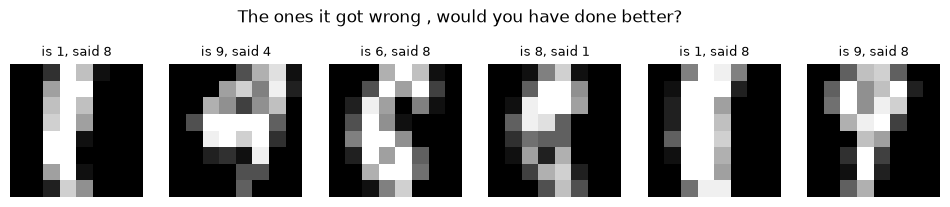

In [9]:
fig, axes = plt.subplots(1, 6, figsize=(12, 2.5))

for ax, i in zip(axes, wrong[:6]):
    ax.imshow(X_test[i].reshape(8, 8), cmap='gray')
    ax.set_title(f"is {y_test[i]}, said {predictions[i]}", fontsize=9)
    ax.axis('off')

plt.suptitle("The ones it got wrong , would you have done better?")
plt.show()

> 💡 **Worth saying out loud.** Some of those are hard for a human too. When a model struggles, the first question isn't "which fancier algorithm should I use", it's "is the information even in the data?" More pixels would help here far more than a cleverer model would.

---
# Part 4 , Text is numbers too, but you have to make them

Now the other half, and the same idea with a twist.

Images arrived as numbers already. Text doesn't. `"the food was great"` is not a number and there's no obvious way to make it one.

The standard trick is called **bag of words**, and it's this:

1. Collect every distinct word that appears anywhere in your text. That's your **vocabulary**.
2. Make one column per word.
3. For each sentence, count how many times each word appears.

You end up with a table. Rows are sentences, columns are words, cells are counts.

It's called a *bag* of words because it throws the order away, tips all the words into a bag and just counts them. That sounds like a terrible idea, and we'll see later that it sometimes is. It also works remarkably well.

In [10]:
from sklearn.feature_extraction.text import CountVectorizer

tiny_reviews = [
    "the food was great",
    "the service was slow",
    "great food and great service",
    "the food was slow to arrive",
]

vectorizer = CountVectorizer()
matrix = vectorizer.fit_transform(tiny_reviews)

print("Vocabulary (every distinct word, alphabetical):")
print(vectorizer.get_feature_names_out())

Vocabulary (every distinct word, alphabetical):
['and' 'arrive' 'food' 'great' 'service' 'slow' 'the' 'to' 'was']


In [11]:
# The whole table, small enough to read every cell.
pd.DataFrame(
    matrix.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=["doc1", "doc2", "doc3", "doc4"],
)

,and,arrive,food,great,service,slow,the,to,was
doc1,0,0,1,1,0,0,1,0,1
doc2,0,0,0,0,1,1,1,0,1
doc3,1,0,1,2,1,0,0,0,0
doc4,0,1,1,0,0,1,1,1,1


**Read that table across, and it clicks.**

Four sentences became four rows. Nine distinct words became nine columns. Every cell is a count.

Look at **doc3**, `"great food and great service"`. The `great` column says **2**, because the word appears twice. And its `the` and `was` columns are 0, because that sentence doesn't contain them.

That's a table of numbers, built out of sentences. Same destination as the images, different route.

> ⚠️ **Notice what's been lost.** `"the food was slow"` and `"was the food slow"` would produce identical rows. Word order is gone completely. Hold that thought for Part 7.

---
# Part 5 , Why raw counts mislead, and what TF-IDF does about it

There's a problem with counting.

The most frequent words in any English text are `the`, `and`, `was`, `to`. They're everywhere, in every sentence, positive and negative alike. Counting them gives them big numbers and therefore lots of influence, and they tell you **nothing** about what a sentence means.

Meanwhile `delicious` might appear once, in one review, and that single appearance is enormously informative.

**TF-IDF** fixes this. The name is off-putting but the idea is simple:

- **TF** (term frequency): how often does this word appear in *this* sentence? Common here, higher score.
- **IDF** (inverse document frequency): how many sentences contain it *overall*? Common everywhere, **lower** score.

Multiply them, and words that are frequent here but rare elsewhere score highest. Those are exactly the words that distinguish one document from another.

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(tiny_reviews)

pd.DataFrame(
    tfidf_matrix.toarray().round(3),
    columns=tfidf.get_feature_names_out(),
    index=["doc1", "doc2", "doc3", "doc4"],
)

,and,arrive,food,great,service,slow,the,to,was
doc1,0.000,0.00,0.470,0.581,0.000,0.000,0.470,0.00,0.470
doc2,0.000,0.00,0.000,0.000,0.550,0.550,0.445,0.00,0.445
doc3,0.471,0.00,0.300,0.742,0.371,0.000,0.000,0.00,0.000
doc4,0.000,0.51,0.326,0.000,0.000,0.402,0.326,0.51,0.326


Compare this against the counting table in Part 4.

In doc3, `great` now scores **0.742**, easily the highest value in that row. It's frequent in that sentence and rare across the others, so TF-IDF rewards it twice over.

Meanwhile `the`, which appeared in three of the four sentences, is pushed down everywhere it shows up. It's common, so it's uninformative, so it's quiet.

> 💡 **The rule of thumb.** `CountVectorizer` is easier to explain and fine for learning. `TfidfVectorizer` usually performs better on real text. They're interchangeable in code, so try both.

---
# Part 6 , Classifying real sentences

Time to do something useful with it. Here are 48 short restaurant reviews, half positive and half negative, labelled by hand.

The task: given a review the model has never seen, decide whether it's positive or negative. That's **sentiment analysis**, and it's the single most common text-analysis job in industry.

In [13]:
positive_reviews = [
    "the food was absolutely delicious and the staff were lovely",
    "great atmosphere and excellent service, will come back",
    "wonderful meal, everything was perfect",
    "really tasty food at a fair price",
    "the best pizza i have had in years",
    "friendly staff and a lovely warm atmosphere",
    "excellent value and the dessert was delicious",
    "quick service and wonderful flavours",
    "perfect evening, the wine was excellent",
    "lovely food and very friendly waiters",
    "delicious starters and a great main course",
    "i loved the meal and the service was quick",
    "beautiful presentation and delicious flavours",
    "the staff were friendly and the food arrived quickly",
    "fantastic value for such tasty food",
    "a lovely evening with excellent wine",
    "the pasta was perfect and the service was friendly",
    "brilliant meal, we will definitely return",
    "fresh ingredients and wonderful service",
    "great coffee and lovely cake",
    "superb food and a warm welcome",
    "tasty portions at a reasonable price",
    "the chef did a fantastic job, delicious",
    "attentive staff and excellent desserts",
]

negative_reviews = [
    "the food was cold and completely tasteless",
    "terrible service, we waited an hour",
    "overpriced and disappointing, would not return",
    "the worst meal i have had this year",
    "rude staff and a dirty table",
    "bland food and slow service",
    "awful experience, the pizza was burnt",
    "disappointing portions for the price",
    "cold soup and rude waiters",
    "terrible atmosphere and burnt food",
    "we waited ages and the food was bland",
    "dirty cutlery and awful service",
    "the meal was overpriced and tasteless",
    "slow service and cold plates",
    "burnt toast and lukewarm coffee",
    "unfriendly staff and a long wait",
    "the worst service we have experienced",
    "greasy food and a dirty floor",
    "expensive and thoroughly disappointing",
    "stale bread and bland soup",
    "rude manager and terrible food",
    "we waited forever for cold pasta",
    "awful value, tiny portions",
    "unpleasant smell and dirty glasses",
]

reviews = positive_reviews + negative_reviews
sentiment = [1] * len(positive_reviews) + [0] * len(negative_reviews)

print("Total reviews:", len(reviews))
print("Positive:", sum(sentiment), " Negative:", len(sentiment) - sum(sentiment))

Total reviews: 48
Positive: 24  Negative: 24


In [14]:
# Step 1: turn the sentences into a table of word counts.
vec = CountVectorizer()
X_text = vec.fit_transform(reviews)

print("Vocabulary size:", len(vec.get_feature_names_out()), "distinct words")
print("Our table:", X_text.shape, " -> 48 reviews, 115 word columns")
print()
print("Cells in the table:", X_text.shape[0] * X_text.shape[1])
print("Cells that aren't zero:", X_text.nnz)
print("So the table is {:.1f}% zeros.".format(100 * (1 - X_text.nnz / (X_text.shape[0] * X_text.shape[1]))))

Vocabulary size: 115 distinct words
Our table: (48, 115)  -> 48 reviews, 115 word columns

Cells in the table: 5520
Cells that aren't zero: 277
So the table is 95.0% zeros.


**95% of that table is zeros**, because any one short review contains only a handful of the 115 words in the vocabulary.

That's completely normal for text and it has a name: the table is **sparse**. It's also why text tables get enormous. With 10,000 reviews and 20,000 distinct words you'd have 200 million cells, nearly all of them zero. (scikit-learn quietly stores only the non-zeros, which is why this doesn't melt your laptop.)

In [15]:
from sklearn.naive_bayes import MultinomialNB

X_tr, X_te, y_tr, y_te = train_test_split(
    X_text, sentiment, test_size=0.25, random_state=42, stratify=sentiment
)

print("Training reviews:", X_tr.shape[0])
print("Test reviews:    ", X_te.shape[0])

text_model = MultinomialNB()
text_model.fit(X_tr, y_tr)

text_predictions = text_model.predict(X_te)
print()
print("Accuracy: {:.4f}".format(accuracy_score(y_te, text_predictions)))

Training reviews: 36
Test reviews:     12

Accuracy: 1.0000


**100%, all 12 test reviews correct.**

Now, be suspicious of that. It is *not* evidence that we've built something brilliant, and a real analyst would say so out loud:

- The test set is only **12 reviews**. Getting all 12 right isn't a big ask.
- The reviews were written to be clearly positive or negative. Real reviews are mixed, sarcastic and ambiguous.
- 48 reviews is a tiny dataset. Real sentiment models train on hundreds of thousands.

> ⚠️ **A suspiciously perfect score usually means the problem was too easy, not that the model is exceptional.** That instinct will serve you well.

`MultinomialNB` is Naive Bayes, by the way, a classifier that works particularly well on word counts. You could swap in logistic regression here and the rest of the code wouldn't change.

---
# Part 7 , What it learned, and where it falls over

Same question we asked of the Titanic model: **what did it actually learn?** For a text classifier we can just ask which words push it each way.

In [16]:
full_model = MultinomialNB().fit(X_text, sentiment)

word_scores = full_model.feature_log_prob_[1] - full_model.feature_log_prob_[0]
words = vec.get_feature_names_out()
order = np.argsort(word_scores)

print("Words that most say POSITIVE:")
print(" ", [words[i] for i in order[-6:]][::-1])
print()
print("Words that most say NEGATIVE:")
print(" ", [words[i] for i in order[:6]])

Words that most say POSITIVE:
  ['lovely', 'excellent', 'delicious', 'friendly', 'perfect', 'great']

Words that most say NEGATIVE:
  ['cold', 'dirty', 'burnt', 'terrible', 'rude', 'waited']


**Positive:** delicious, excellent, lovely, friendly, wonderful, perfect
**Negative:** dirty, cold, bland, burnt, awful, disappointing

Nothing surprising, and that's the point. The model learned sensible things, and you can check that it did. Whenever a model's learned features look strange, that's a signal something's wrong with your data.

Now let's give it some new sentences.

In [17]:
new_reviews = [
    "the service was terrible and the food was cold",
    "absolutely delicious, lovely staff",
    "the pizza was burnt but the staff were friendly",
]

for review in new_reviews:
    row = vec.transform([review])
    prediction = full_model.predict(row)[0]
    confidence = full_model.predict_proba(row)[0].max()
    label = "POSITIVE" if prediction == 1 else "NEGATIVE"
    print(f"{label}  (confidence {confidence:.3f})   {review!r}")

NEGATIVE  (confidence 0.871)   'the service was terrible and the food was cold'
POSITIVE  (confidence 0.989)   'absolutely delicious, lovely staff'
POSITIVE  (confidence 0.934)   'the pizza was burnt but the staff were friendly'


The first two are exactly right, and confidently so.

**The third one is the interesting one.** *"the pizza was burnt but the staff were friendly"* comes back **POSITIVE with 93% confidence**, and most people would read that as a complaint with a polite caveat.

Why did it go wrong? Because of the thing we flagged back in Part 4: **bag of words throws away word order.** The model sees `burnt` (negative) and `friendly` (positive) sitting in the same bag, and the positive words happen to win the count.

It has no idea what `but` means. It doesn't know that `but` signals the important half of a sentence is coming. It can't, because it never sees the sentence, only the bag.

> 💡 **This is genuinely where the field goes next.** Everything since, n-grams, word embeddings, transformers, ChatGPT, is fundamentally about not throwing the order away. When people say modern language models "understand context", this specific failure is a large part of what they mean.

---
---
# Part 8 , Your turn

Three short challenges. Fill in the `# --- YOUR CODE ---` blocks, and the solutions are at the bottom.

## Challenge 1 , Look at an image yourself

Pick any image from the set and inspect it both ways.

Image 1500 - label is 1
[[ 0  0  0  3 12 12  2  0]
 [ 0  0  7 15 16 16  0  0]
 [ 0  4 15  9 14 16  3  0]
 [ 0  2  0  0 14 16  0  0]
 [ 0  0  0  0 14 16  0  0]
 [ 0  0  0  0 15 13  0  0]
 [ 0  0  0  0 16 14  1  0]
 [ 0  0  0  3 16 13  2  0]]


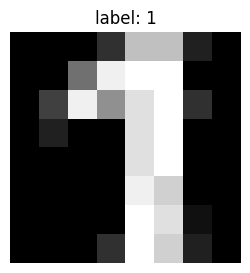

In [ ]:
# Lesson:
#   digits.images[i]  is the 8x8 grid
#   digits.target[i]  is its label
#   plt.imshow(grid, cmap='gray')  draws it

# --- YOUR CODE ---
# 1. Choose an index between 0 and 1796.
# 2. Print its 8x8 grid as integers.
# 3. Draw it with imshow, with its label as the title.
# 4. Can you see the digit in the numbers before you plot it?

i = 96
# print("image", i, "label is", digits.target[i])
print("Image", i, "- label is", digits.target[i])
print(digits.images[i].astype(int))

plt.figure(figsize=(3, 3))
plt.imshow(digits.images[i], cmap='gray')
plt.title(f"label: {digits.target[i]}")
plt.axis('off')
plt.show()



## Challenge 2 , Does TF-IDF do better?

We classified the reviews using plain word counts. Try TF-IDF instead and see whether it helps.

In [19]:
# Lesson:
# Swap CountVectorizer for TfidfVectorizer. Everything else stays the same,
# which is the nice thing about scikit-learn's design.

# --- YOUR CODE ---
# 1. Build a TfidfVectorizer and fit_transform the reviews.
# 2. Split with the SAME settings (test_size=0.25, random_state=42, stratify).
# 3. Train a MultinomialNB and print the accuracy.
# 4. Better, worse, or the same? Why might that be, on data this small?




## Challenge 3 , Break it on purpose

You've seen one sentence fool the model. Find more.

In [20]:
# Lesson:
#   row = vec.transform([your_sentence])
#   full_model.predict(row)  and  full_model.predict_proba(row)

# --- YOUR CODE ---
# Write three sentences you think will fool it, and test them. Ideas:
#   - sarcasm: "oh brilliant, another hour of waiting"
#   - negation: "the food was not good at all"
#   - mixed:    "lovely staff, terrible food"
# For each one, was it right? And can you explain the failure using
# what you know about bag of words?




---
# What to take away

1. **Both topics are the same trick.** Turn unstructured data into a table of numbers, then use the machine learning you already know.
2. **Images are numbers already.** Flatten the grid into a row and you have a table.
3. **Text has to be converted.** Bag of words counts words; TF-IDF weights them by how informative they are.
4. **Look at the mistakes.** The 1-versus-8 confusion and the "burnt but friendly" failure taught us more than the accuracy scores did.
5. **Bag of words throws away order**, and everything modern in language AI is about putting it back.

> ❗**Something to notice.** Both models here were plain classifiers, the same family you met on the Titanic. Tomorrow you meet neural networks, which are what you reach for when flattening a picture into a row loses too much, because a flat row has no idea which pixels were next to each other.

---
---
# SOLUTIONS

### Challenge 1 , Look at an image

Image 42 - label is 1
[[ 0  0  0  0 12  5  0  0]
 [ 0  0  0  2 16 12  0  0]
 [ 0  0  1 12 16 11  0  0]
 [ 0  2 12 16 16 10  0  0]
 [ 0  6 11  5 15  6  0  0]
 [ 0  0  0  1 16  9  0  0]
 [ 0  0  0  2 16 11  0  0]
 [ 0  0  0  3 16  8  0  0]]


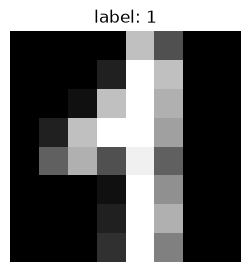

In [21]:
i = 42   # any index from 0 to 1796

print("Image", i, "- label is", digits.target[i])
print(digits.images[i].astype(int))

plt.figure(figsize=(3, 3))
plt.imshow(digits.images[i], cmap='gray')
plt.title(f"label: {digits.target[i]}")
plt.axis('off')
plt.show()

# The bright path of high numbers traces the pen stroke. Once you know to
# look for it, the digit is visible in the grid before you plot anything.

### Challenge 2 , TF-IDF

In [ ]:
tfidf_vec = TfidfVectorizer()
X_tfidf = tfidf_vec.fit_transform(reviews)

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_tfidf, sentiment, test_size=0.25, random_state=42, stratify=sentiment
)

tfidf_model = MultinomialNB().fit(X_tr2, y_tr2)
tfidf_accuracy = accuracy_score(y_te2, tfidf_model.predict(X_te2))

print("Word counts: 1.0000")
print("TF-IDF:      {:.4f}".format(tfidf_accuracy))

# Identical, because counting already got every test review right, so there
# was no room to improve. On a bigger, messier dataset TF-IDF would normally
# pull ahead. With 12 test reviews you simply cannot tell the two apart, and
# "we can't tell from this data" is a perfectly respectable finding.

NameError: name 'CountVectorizer' is not defined

### Challenge 3 , Break it

In [23]:
tricky = [
    "oh brilliant, another hour of waiting",     # sarcasm
    "the food was not good at all",              # negation
    "lovely staff, terrible food",               # mixed
]

for review in tricky:
    row = vec.transform([review])
    prediction = full_model.predict(row)[0]
    confidence = full_model.predict_proba(row)[0].max()
    label = "POSITIVE" if prediction == 1 else "NEGATIVE"
    print(f"{label}  (confidence {confidence:.3f})   {review!r}")

# All three are hard for the same underlying reason.
#
# Sarcasm: it actually answered NEGATIVE, but look at the confidence, 0.539,
#   which is barely better than tossing a coin. And it got there by accident:
#   'waiting' and 'hour' appear in negative training reviews, so those words
#   dragged it over the line. It has no idea 'brilliant' was meant bitterly.
#   Right answer, wrong reasoning, and the confidence score gives it away.
#
# Negation: the model sees 'good' and counts it as positive. The word 'not'
#   is just another word in the bag, sitting there with no power to flip the
#   meaning of the word after it.
#
# Mixed: it comes down to which side has more, or stronger, words. There is
#   no sense of which half of the sentence mattered more.
#
# Every one of these is the same flaw: the order of the words is gone.

NEGATIVE  (confidence 0.539)   'oh brilliant, another hour of waiting'
POSITIVE  (confidence 0.725)   'the food was not good at all'
POSITIVE  (confidence 0.646)   'lovely staff, terrible food'
